## 1. Setup: Install Dependencies

Installs `yfinance` (market data) and `statsmodels` (statistical tests: ADF,
cointegration). Everything else (pandas, numpy, matplotlib, scipy) ships with Colab.

In [1]:
!pip install yfinance statsmodels -q

Import base dataset, including 14 plus stock tickers, which, when paried together result in 14 choose 2 pairs  = 91 possible combinations - analysis is conducted on each of these 91 combinations

## 2. Data Pipeline: Pull Prices & Compute Log Returns

Universe: 15 regional/super-regional bank stocks (chosen as a single sector so any
cointegrated pair we find later has a plausible economic story, not just a
statistical coincidence).

- `download_prices`: pulls daily adjusted close prices from Yahoo Finance
- `clean_prices`: drops tickers with >5% missing data, forward-fills small gaps
- `log_returns`: computes daily log returns (used over simple returns because they're
  additive across time, which makes rolling-window stats cleaner)

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

# --- Data loading ---
def download_prices(tickers, start="2015-01-01", end=None):
    # yfinance returns MultiIndex columns for multi-ticker downloads
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    prices = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw[["Close"]]
    prices = prices.dropna(how="all")
    return prices

def clean_prices(prices, max_missing_frac=0.05):
    # Drop tickers missing too much data rather than silently filling large gaps
    missing_frac = prices.isna().mean()
    keep_cols = missing_frac[missing_frac <= max_missing_frac].index
    dropped = set(prices.columns) - set(keep_cols)
    if dropped:
        print(f"Dropping tickers with too much missing data: {sorted(dropped)}")
    cleaned = prices[keep_cols].ffill().dropna()
    return cleaned

def log_returns(prices):
    # log(P_t / P_t-1) -- additive across time, standard for return-distribution work
    return np.log(prices/prices.shift(1)).dropna()

# Regional bank universe -- one sector, so pairs found later share real macro drivers
universe = ["JPM", "BAC", "WFC", "C", "USB", "PNC", "TFC", "MTB",
            "KEY", "CFG", "HBAN", "RF", "ZION", "FITB", "CMA"]

prices = download_prices(universe, start="2015-01-01")
prices = clean_prices(prices) # CMA gets dropped here -- check why before trusting it
rets = log_returns(prices)

print(f"Prices shape: {prices.shape}")
print(f"Returns shape: {rets.shape}")
prices.tail()

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CMA"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['CMA']: YFTzMissingError('possibly delisted; no timezone found')


Dropping tickers with too much missing data: ['CMA']
Prices shape: (2926, 14)
Returns shape: (2925, 14)


Ticker,BAC,C,CFG,FITB,HBAN,JPM,KEY,MTB,PNC,RF,TFC,USB,WFC,ZION
Date,,,,,,,,,,,,,,
2026-08-17,63.889999,138.509995,74.309998,57.599998,17.950001,360.959991,23.040001,252.860001,254.550003,31.700001,52.529999,64.870003,87.540001,71.580002
2026-08-18,64.230003,137.649994,73.459999,57.290001,17.660000,363.250000,22.790001,251.500000,254.279999,31.700001,52.410000,64.790001,87.400002,70.930000
2026-08-19,63.169998,132.889999,70.760002,54.959999,17.170000,357.260010,22.100000,244.550003,246.460007,30.590000,50.970001,62.820000,85.940002,68.290001
2026-08-20,61.860001,129.669998,69.709999,54.500000,17.010000,351.549988,21.850000,238.250000,241.619995,30.219999,50.230000,61.779999,83.699997,67.889999
2026-08-21,61.689999,131.649994,69.860001,54.820000,17.030001,351.579987,21.870001,240.339996,243.130005,30.410000,50.419998,62.049999,83.839996,68.139999


## 3. Return Distribution Diagnostics

Checks whether daily returns behave like a normal ("bell curve") distribution.
Spoiler: they won't -- this step quantifies HOW non-normal they are, which directly
informs how wide our later z-score thresholds need to be.

- **Skew**: asymmetry. Negative = crashes bigger than rallies (typical for equities).
- **Excess kurtosis**: how much fatter the tails are than a normal distribution
  predicts. Higher = more frequent extreme moves than a naive model would expect.
- **Jarque-Bera test**: formal test of normality. p < 0.05 = reject normality.

In [3]:
from scipy import stats
import matplotlib.pyplot as plt

# --- Return distribution diagnostics ---
def summarize_returns(rets):
    # annualized_vol assumes 252 trading days/year, the standard convention
    summary = pd.DataFrame({
        "mean_daily": rets.mean(),
        "std_daily": rets.std(),
        "annualized_vol": rets.std() * np.sqrt(252),
        "skew": rets.apply(lambda x: stats.skew(x)),
        "excess_kurtosis": rets.apply(lambda x: stats.kurtosis(x)), # 0 = normal-like
    })
    return summary.sort_values("annualized_vol")

def normality_test(rets):
    # Jarque-Bera jointly tests skew + kurtosis against normal-distribution expectations
    results = {}
    for col in rets.columns:
        stat, pval = stats.jarque_bera(rets[col].dropna())
        results[col] = pval
    return pd.Series(results, name="jarque_bera_pvalue").sort_values()

summary = summarize_returns(rets)
print("=== Return summary stats ===")
print(summary.round(4))

print("\n=== Jarque-Bera normality test (p < 0.05 => reject normality) ===")
print(normality_test(rets).round(6))

=== Return summary stats ===
        mean_daily  std_daily  annualized_vol    skew  excess_kurtosis
Ticker                                                                
JPM         0.0007     0.0170          0.2692 -0.0847          12.7095
PNC         0.0005     0.0181          0.2876 -0.3404           9.4822
USB         0.0002     0.0184          0.2925 -0.2949          10.2289
BAC         0.0005     0.0191          0.3034 -0.1453           9.7404
WFC         0.0003     0.0196          0.3106 -0.2721           8.7369
MTB         0.0003     0.0199          0.3162  0.1788          11.3226
TFC         0.0002     0.0205          0.3249 -0.7013          13.4635
C           0.0004     0.0206          0.3275 -0.5017          12.9477
HBAN        0.0003     0.0211          0.3343 -0.3337           8.7711
RF          0.0005     0.0222          0.3525 -0.6114          10.3218
FITB        0.0005     0.0222          0.3532 -0.6320          13.9254
CFG         0.0005     0.0233          0.3704 -0

## 4. Visualize Fat Tails

Plots the most and least volatile stock's actual return histogram against a fitted
normal curve with the same mean/std, so the fat-tail gap is visible, not just numeric.

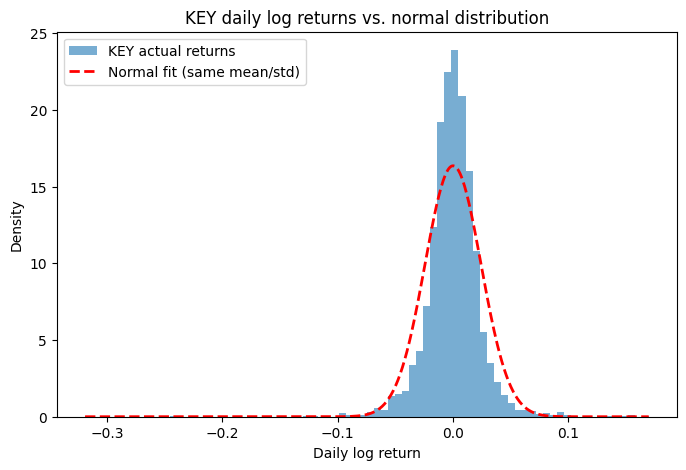

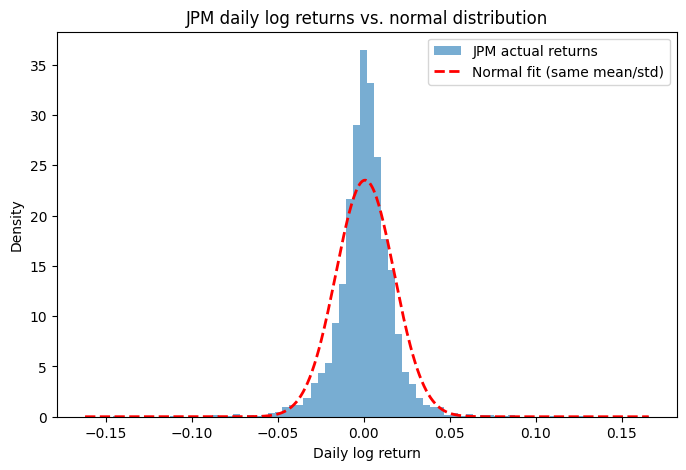

In [4]:
# --- Distribution plots: actual returns vs. fitted normal ---
def plot_distribution(rets, ticker):
    x = rets[ticker].dropna()
    mu, sigma = x.mean(), x.std()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(x, bins=80, density=True, alpha=0.6, label=f"{ticker} actual returns")
    grid = np.linspace(x.min(), x.max(), 500)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "r--", linewidth=2, label="Normal fit (same mean/std)")
    ax.set_title(f"{ticker} daily log returns vs. normal distribution")
    ax.set_xlabel("Daily log return")
    ax.set_ylabel("Density")
    ax.legend()
    plt.show()

most_vol = summary["annualized_vol"].idxmax()
least_vol = summary["annualized_vol"].idxmin()
plot_distribution(rets, most_vol)
plot_distribution(rets, least_vol)

## 5. Cointegration Screen: Finding a Real Pair

Correlation (moves together day-to-day) is NOT the same as cointegration (the
*spread* between two stocks reverts to a stable relationship). We test every pair
for the latter using the Engle-Granger method, cross-checked with a direct ADF test
on the same spread. Low p-value = strong evidence the pair is genuinely cointegrated,
not just coincidentally correlated in this sample window.

In [5]:
!pip install statsmodels -q
from itertools import combinations
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm

# --- Cointegration screening across all pairs ---
def hedge_ratio(price_a, price_b):
    # OLS: price_a = alpha + beta * price_b. Beta mostly corrects for the two
    # stocks trading at different price levels -- not a deep economic signal.
    x = sm.add_constant(price_b)
    model = sm.OLS(price_a, x).fit()
    return model.params.iloc[1]

def compute_spread(price_a, price_b, beta):
    return price_a - beta * price_b # the series we'll actually trade

def screen_pairs(prices, significance=0.05):
    results = []
    tickers = prices.columns.tolist()
    for a, b in combinations(tickers, 2):
        price_a, price_b = prices[a], prices[b]
        correlation = price_a.corr(price_b) # context only, NOT the selection criterion
        try:
            eg_stat, eg_pvalue, _ = coint(price_a, price_b) # Engle-Granger (built-in ADF step)
        except Exception:
            continue
        beta = hedge_ratio(price_a, price_b)
        spread = compute_spread(price_a, price_b, beta)
        adf_stat, adf_pvalue, *_ = adfuller(spread) # independent cross-check on the spread
        results.append({
            "pair": f"{a}-{b}", "stock_a": a, "stock_b": b,
            "correlation": correlation, "hedge_ratio": beta,
            "eg_pvalue": eg_pvalue, "adf_pvalue": adf_pvalue,
            "cointegrated": eg_pvalue < significance and adf_pvalue < significance,
        })
    return pd.DataFrame(results).sort_values("eg_pvalue")

screen = screen_pairs(prices)
print(f"Total pairs tested: {len(screen)}")
print(f"Pairs passing both tests at 5%: {screen['cointegrated'].sum()}")
print(screen.head(10).to_string(index=False))

Total pairs tested: 91
Pairs passing both tests at 5%: 9
    pair stock_a stock_b  correlation  hedge_ratio  eg_pvalue  adf_pvalue  cointegrated
FITB-PNC    FITB     PNC     0.991363     0.239227   0.000620    0.000094          True
 BAC-PNC     BAC     PNC     0.988146     0.260766   0.001080    0.000172          True
KEY-ZION     KEY    ZION     0.975258     0.299579   0.004635    0.000864          True
BAC-FITB     BAC    FITB     0.980363     1.072111   0.014591    0.003174          True
  BAC-RF     BAC      RF     0.974898     1.869250   0.017104    0.003822          True
HBAN-JPM    HBAN     JPM     0.919050     0.036237   0.021074    0.004846          True
TFC-ZION     TFC    ZION     0.950778     0.617579   0.026817    0.006421          True
 HBAN-RF    HBAN      RF     0.969940     0.479513   0.029448    0.007163          True
HBAN-PNC    HBAN     PNC     0.967214     0.065811   0.041719    0.010820          True
 KEY-TFC     KEY     TFC     0.962205     0.455036   0.051349  

## 6. Build the Trading Signal (FITB-PNC)

Converts the spread into a rolling z-score: "how many standard deviations from its
own recent average is the spread right now?" Entry threshold is deliberately WIDE
(z = 2.0, not 1.0) because of the fat tails found in Step 3 -- a tight threshold
would trigger constantly on ordinary noise. Position is held until the spread
reverts back inside the exit threshold.

In [6]:
# --- Z-score signal construction ---
def build_spread(price_a, price_b, hedge_ratio):
    return price_a - hedge_ratio * price_b

def rolling_zscore(spread, window=60):
    # Rolling (not full-history) mean/std so the signal adapts to recent behavior
    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()
    return (spread - rolling_mean) / rolling_std

def generate_signal(z, entry_threshold=2.0, exit_threshold=0.5):
    # +1 = long the spread (buy A, sell B) | -1 = short the spread (sell A, buy B)
    position = pd.Series(0, index=z.index, dtype=int)
    position = pd.Series(0, index=z.index, dtype=int)
    current_position = 0
    for i in range(len(z)):
        zi = z.iloc[i]
        if pd.isna(zi):
            position.iloc[i] = current_position
            continue
        if current_position == 0:
            if zi > entry_threshold:
                current_position = -1
            elif zi < -entry_threshold:
                current_position = 1
        else:
            if abs(zi) < exit_threshold: # reverted -> close out
                current_position = 0
        position.iloc[i] = current_position
    return position

stock_a, stock_b = "FITB", "PNC"
hedge = 0.239227 # from the cointegration screen above

spread = build_spread(prices[stock_a], prices[stock_b], hedge)
z = rolling_zscore(spread, window=60)
position = generate_signal(z, entry_threshold=2.0, exit_threshold=0.5)

print(f"Days with a position on: {(position != 0).sum()} / {len(position)}")
print(f"Long spread days: {(position == 1).sum()}, Short spread days: {(position == -1).sum()}")

Days with a position on: 1096 / 2926
Long spread days: 516, Short spread days: 580


## 7. Visualize the Spread & Signal

Bottom panel: orange = z-score, red dashed = entry thresholds, green dotted = exit
thresholds. Every crossing past red is an entry; crossing back inside green is an exit.

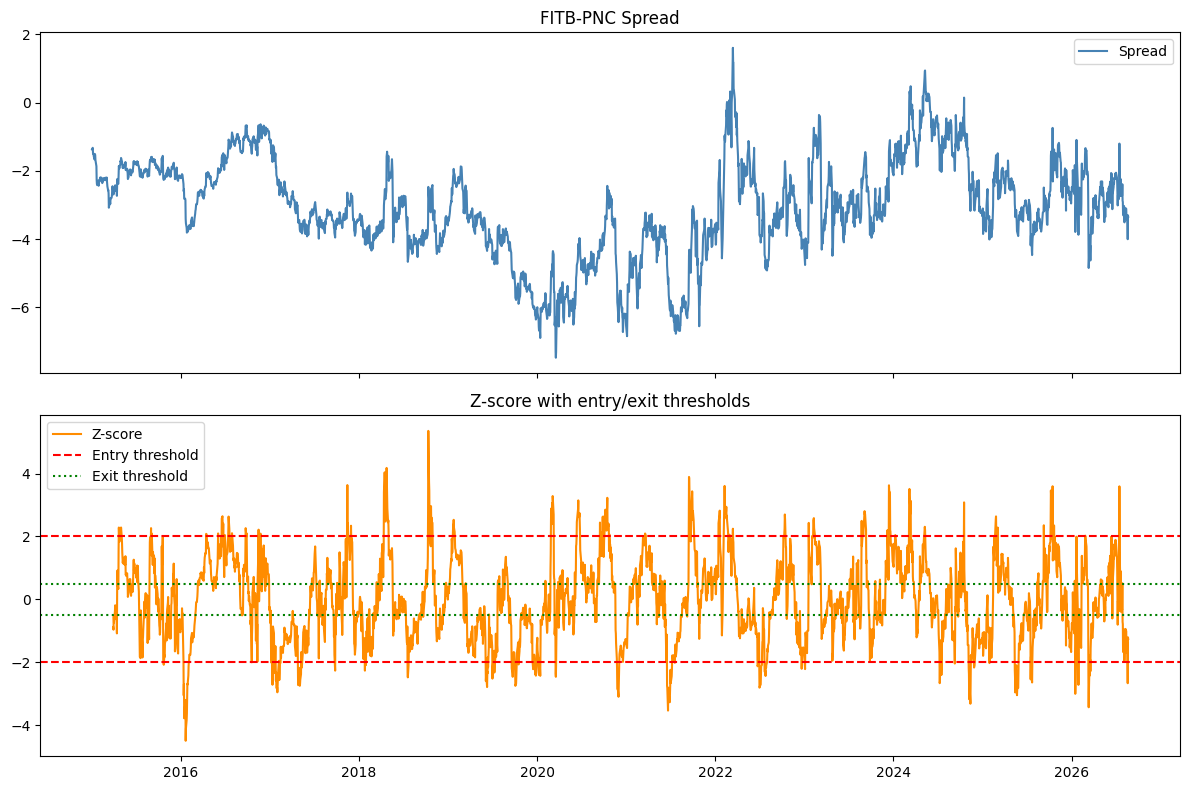

In [7]:
import matplotlib.pyplot as plt

# --- Spread and z-score chart ---
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(spread.index, spread, label="Spread", color="steelblue")
axes[0].set_title(f"{stock_a}-{stock_b} Spread")
axes[0].legend()

axes[1].plot(z.index, z, label="Z-score", color="darkorange")
axes[1].axhline(2.0, color="red", linestyle="--", label="Entry threshold")
axes[1].axhline(-2.0, color="red", linestyle="--")
axes[1].axhline(0.5, color="green", linestyle=":", label="Exit threshold")
axes[1].axhline(-0.5, color="green", linestyle=":")
axes[1].set_title("Z-score with entry/exit thresholds")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Backtest — No Costs, No Out-of-Sample Split (Sanity Check Only)

This version is deliberately naive with no transaction costs, no train/test split.
Treat any "good-looking" result here with suspicion; it's a first sanity check, not
a validated result. Positions are lagged by one day (`shift(1)`) to avoid lookahead
bias -- you can only trade on yesterday's signal, not today's.

## 9. Out-of-Sample Validation - The Honesty Check

Splits performance at 2020-01-01 (chosen after seeing the full equity curve had a
visible behavior change there -- a limitation worth naming, not hiding). If the
strategy only "works" in one period, the full-sample number is misleading.

=== Performance summary (NO costs, NO out-of-sample split yet) ===
total_return: 2.2374
annualized_return: 0.1065
annualized_vol: 0.1878
sharpe_ratio: 0.5672
max_drawdown: -0.2695
num_trading_days: 2925


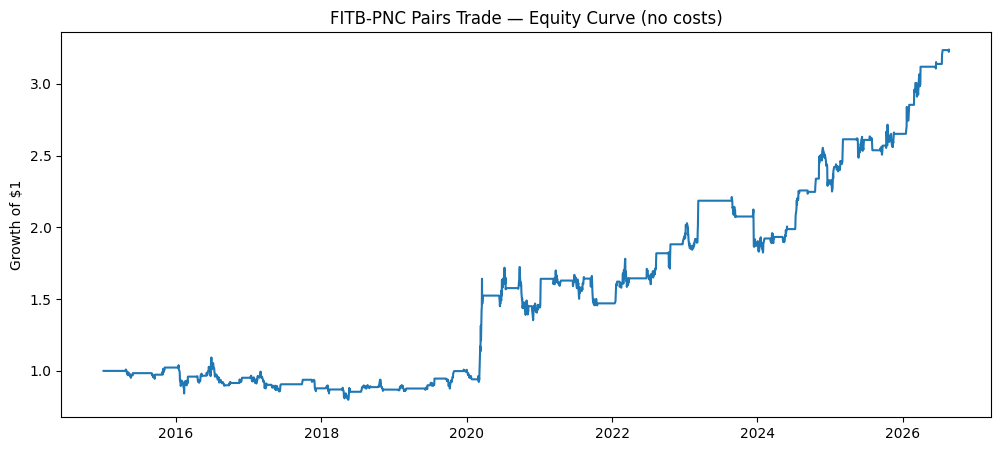

In [8]:
# --- Naive backtest (no costs yet) ---
def compute_spread_pnl(price_a, price_b, hedge_ratio, position):
    ret_a = price_a.pct_change()
    ret_b = price_b.pct_change()
    spread_return = ret_a - hedge_ratio * ret_b
    lagged_position = position.shift(1).fillna(0)
    strategy_return = lagged_position * spread_return
    equity_curve = (1 + strategy_return.fillna(0)).cumprod()
    return pd.DataFrame({
        "spread_return": spread_return, "position": position,
        "lagged_position": lagged_position, "strategy_return": strategy_return,
        "equity_curve": equity_curve,
    })

def performance_summary(strategy_return, periods_per_year=252):
    clean = strategy_return.dropna()
    total_return = (1 + clean).prod() - 1
    annualized_return = (1 + total_return) ** (periods_per_year / len(clean)) - 1
    annualized_vol = clean.std() * np.sqrt(periods_per_year)
    sharpe = annualized_return / annualized_vol if annualized_vol > 0 else np.nan
    cumulative = (1 + clean).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    return {
        "total_return": total_return, "annualized_return": annualized_return,
        "annualized_vol": annualized_vol, "sharpe_ratio": sharpe,
        "max_drawdown": max_drawdown, "num_trading_days": len(clean),
    }

result = compute_spread_pnl(prices[stock_a], prices[stock_b], hedge, position)
summary = performance_summary(result["strategy_return"])

print("=== Performance summary (NO costs, NO out-of-sample split yet) ===")
for k, v in summary.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

plt.figure(figsize=(12, 5))
plt.plot(result.index, result["equity_curve"])
plt.title(f"{stock_a}-{stock_b} Pairs Trade — Equity Curve (no costs)")
plt.ylabel("Growth of $1")
plt.show()

In [9]:
def apply_transaction_costs(strategy_return, lagged_position, cost_bps=5.0):
    position_change = lagged_position.diff().abs().fillna(0)
    cost = position_change * (cost_bps / 10000)
    return strategy_return - cost

def run_full_backtest(price_a, price_b, hedge_ratio, position, cost_bps=5.0):
    ret_a = price_a.pct_change()
    ret_b = price_b.pct_change()
    spread_return = ret_a - hedge_ratio * ret_b
    lagged_position = position.shift(1).fillna(0)
    gross_return = lagged_position * spread_return
    net_return = apply_transaction_costs(gross_return, lagged_position, cost_bps)
    equity_curve = (1 + net_return.fillna(0)).cumprod()
    return net_return, equity_curve

def performance_summary(strategy_return, periods_per_year=252):
    clean = strategy_return.dropna()
    if len(clean) == 0 or clean.std() == 0:
        return {"total_return": np.nan, "annualized_return": np.nan, "annualized_vol": np.nan,
                "sharpe_ratio": np.nan, "max_drawdown": np.nan, "num_trading_days": len(clean)}
    total_return = (1 + clean).prod() - 1
    annualized_return = (1 + total_return) ** (periods_per_year / len(clean)) - 1
    annualized_vol = clean.std() * np.sqrt(periods_per_year)
    sharpe = annualized_return / annualized_vol if annualized_vol > 0 else np.nan
    cumulative = (1 + clean).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    return {"total_return": total_return, "annualized_return": annualized_return,
            "annualized_vol": annualized_vol, "sharpe_ratio": sharpe,
            "max_drawdown": max_drawdown, "num_trading_days": len(clean)}

# --- Out-of-sample train/test split ---
def train_test_split_backtest(price_a, price_b, hedge_ratio, position, split_date, cost_bps=5.0):
    net_return, _ = run_full_backtest(price_a, price_b, hedge_ratio, position, cost_bps)
    train_return = net_return[net_return.index < split_date]
    test_return = net_return[net_return.index >= split_date]
    return {"train": performance_summary(train_return), "test": performance_summary(test_return)}

print("=== OUT-OF-SAMPLE SPLIT (train < 2020, test >= 2020) ===")
split_results = train_test_split_backtest(prices[stock_a], prices[stock_b], hedge, position, "2020-01-01")
for period, summary in split_results.items():
    print(f"\n--- {period.upper()} ---")
    for k, v in summary.items():
        print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

=== OUT-OF-SAMPLE SPLIT (train < 2020, test >= 2020) ===

--- TRAIN ---
  total_return: -0.0215
  annualized_return: -0.0044
  annualized_vol: 0.1445
  sharpe_ratio: -0.0301
  max_drawdown: -0.2760
  num_trading_days: 1257

--- TEST ---
  total_return: 2.1240
  annualized_return: 0.1878
  annualized_vol: 0.2146
  sharpe_ratio: 0.8753
  max_drawdown: -0.2157
  num_trading_days: 1668


## 10. Extend Validation to All 9 Cointegrated Pairs

Does the pre/post-2020 break only affect FITB-PNC, or is it sector-wide? Runs the
identical signal + backtest + OOS split pipeline across every pair that passed the
cointegration screen, so results are comparable apples-to-apples.

**Bar for "survives":** train_sharpe > 0 AND test_sharpe > 0.5 -- intentionally
strict, requiring genuine edge in BOTH periods, not just a good post-2020 number.

In [10]:
# --- Multi-pair out-of-sample comparison ---
candidates = [
    ("FITB", "PNC", 0.239227),
    ("BAC", "PNC", 0.260766),
    ("KEY", "ZION", 0.299579),
    ("BAC", "FITB", 1.072111),
    ("BAC", "RF", 1.869250),
    ("HBAN", "JPM", 0.036237),
    ("TFC", "ZION", 0.617579),
    ("HBAN", "RF", 0.479513),
    ("HBAN", "PNC", 0.065811),
]

def evaluate_pair(prices, stock_a, stock_b, hedge_ratio, split_date="2020-01-01"):
    spread = prices[stock_a] - hedge_ratio * prices[stock_b]
    z = rolling_zscore(spread, window=60)
    position = generate_signal(z, entry_threshold=2.0, exit_threshold=0.5)
    split_results = train_test_split_backtest(prices[stock_a], prices[stock_b], hedge_ratio, position, split_date)
    return {
        "pair": f"{stock_a}-{stock_b}",
        "train_sharpe": split_results["train"]["sharpe_ratio"],
        "train_return": split_results["train"]["annualized_return"],
        "test_sharpe": split_results["test"]["sharpe_ratio"],
        "test_return": split_results["test"]["annualized_return"],
        "test_max_dd": split_results["test"]["max_drawdown"],
    }

results = [evaluate_pair(prices, a, b, h) for a, b, h in candidates]
results_df = pd.DataFrame(results)
results_df["survives_oos"] = (results_df["train_sharpe"] > 0) & (results_df["test_sharpe"] > 0.5)
print(results_df.round(3).to_string(index=False))

    pair  train_sharpe  train_return  test_sharpe  test_return  test_max_dd  survives_oos
FITB-PNC        -0.030        -0.004        0.875        0.188       -0.216         False
 BAC-PNC        -0.183        -0.026        0.164        0.031       -0.405         False
KEY-ZION         0.422         0.058       -0.079       -0.020       -0.372         False
BAC-FITB         0.483         0.050        0.082        0.014       -0.260         False
  BAC-RF         0.349         0.075        0.161        0.056       -0.557         False
HBAN-JPM         0.411         0.069       -0.209       -0.061       -0.578         False
TFC-ZION         1.042         0.069        0.456        0.077       -0.227         False
 HBAN-RF         0.517         0.052        0.089        0.015       -0.316         False
HBAN-PNC         0.355         0.057        0.270        0.070       -0.346         False


## 11. Parameter Stability Check

Re-runs the train/test split across a 3x3 grid of rolling windows (45/60/75 days)
and entry thresholds (1.5/2.0/2.5σ) on FITB-PNC. Goal: confirm the pre/post-2020
break isn't an artifact of one arbitrary parameter choice -- if it's structural,
it should show up consistently across the whole grid, not just at window=60, entry=2.0.

In [11]:
# --- Parameter stability grid ---
def parameter_stability_test(prices, stock_a, stock_b, hedge_ratio,
                              windows=(45, 60, 75), entry_thresholds=(1.5, 2.0, 2.5)):
    spread = prices[stock_a] - hedge_ratio * prices[stock_b]
    results = []
    for window in windows:
        z = rolling_zscore(spread, window=window)
        for entry in entry_thresholds:
            position = generate_signal(z, entry_threshold=entry, exit_threshold=0.5)
            split_results = train_test_split_backtest(prices[stock_a], prices[stock_b], hedge_ratio, position, "2020-01-01")
            results.append({
                "window": window, "entry_threshold": entry,
                "train_sharpe": split_results["train"]["sharpe_ratio"],
                "test_sharpe": split_results["test"]["sharpe_ratio"],
            })
    return pd.DataFrame(results)


# Every combination shows the same pattern: near-zero/negative train Sharpe,
# consistently strong test Sharpe -- the break tracks the CALENDAR, not the parameters
stability_df = parameter_stability_test(prices, "FITB", "PNC", 0.239227)
print(stability_df.round(3).to_string(index=False))

 window  entry_threshold  train_sharpe  test_sharpe
     45              1.5         0.054        0.597
     45              2.0        -0.089        0.668
     45              2.5        -0.351        0.779
     60              1.5         0.296        0.712
     60              2.0        -0.030        0.875
     60              2.5        -0.209        1.028
     75              1.5         0.111        0.827
     75              2.0         0.038        0.914
     75              2.5        -0.192        1.141


## Verdict: REJECTED

None of the 9 cointegrated pairs show a consistently positive Sharpe ratio across
both the pre-2020 and post-2020 periods. The full-sample FITB-PNC result (Sharpe
0.57) is explained by a regime break, not a durable structural edge.


# Research Note: Statistical Arbitrage in Regional Bank Pairs

## Question

Can a cointegration-based pairs trading strategy on regional bank stocks generate
positive, risk-adjusted, out-of-sample returns net of realistic transaction costs?

## Data

Daily adjusted close prices, 2015-01-01 through present, for 14 regional/super-regional
bank stocks: JPM, BAC, WFC, C, USB, PNC, TFC, MTB, KEY, CFG, HBAN, RF, ZION, FITB.
(CMA was dropped during cleaning due to excessive missing data.) Source: Yahoo Finance
via `yfinance`.

## Method

1. **Return distribution check.** Computed daily log returns and tested for normality
   (Jarque-Bera). All 14 stocks rejected normality at p < 0.001, with excess kurtosis
   ranging from ~8.7 (WFC) to ~21.6 (KEY) and predominantly negative skew — consistent
   with the well-documented fat-tailed, left-skewed behavior of equity returns. This
   motivated using wider (not tighter) entry thresholds for the mean-reversion signal,
   since a fat-tailed series produces more "extreme-looking" moves that are actually
   just noise.

2. **Cointegration screen.** Tested all 91 pairs among the 14 stocks using the
   Engle-Granger method (OLS regression for the hedge ratio, then an ADF test on the
   residual spread), cross-checked with a direct ADF test on the same spread. 9 of 91
   pairs passed both tests at the 5% significance level. The top candidate, FITB-PNC
   (Engle-Granger p = 0.0006), was selected first based on statistical strength and a
   plausible economic rationale (similarly-sized regional banks with overlapping
   footprints and shared macro exposure).

3. **Signal construction.** Built a rolling 60-day z-score of the spread
   (`spread = price_A - hedge_ratio * price_B`), with entry at |z| > 2.0 and exit at
   |z| < 0.5. Positions are lagged by one day to avoid lookahead bias.

4. **Backtest and validation.** Ran the signal through a full backtest (no costs) for
   an initial sanity check, then applied the actual validation step: a strict
   out-of-sample split at 2020-01-01, chosen because visual inspection of the
   full-sample equity curve showed a clear behavioral break around that date.

## Results

**FITB-PNC, full sample (no costs):** total return 224%, annualized return 10.7%,
Sharpe 0.57, max drawdown -27%. On the surface, a plausible-looking result.

**FITB-PNC, out-of-sample split:**

| Period | Sharpe | Annualized return |
|---|---|---|
| Train (pre-2020) | -0.03 | -0.4% |
| Test (2020+) | 0.88 | 18.8% |

The strategy showed no real edge before 2020 and only became profitable afterward.
This is a critical finding: the full-sample Sharpe of 0.57 is not evidence of a
consistent, structural edge; it is the average of a period with no edge and a period
with an edge, and there is no basis for assuming the post-2020 behavior will persist
rather than reverting to the pre-2020 pattern (or something else entirely).

**Extended to all 9 statistically cointegrated pairs**, applying the same 60-day
window, 2.0 entry threshold, and 2020 split:

| Pair | Train Sharpe | Test Sharpe |
|---|---|---|
| FITB-PNC | -0.03 | 0.88 |
| BAC-PNC | -0.18 | 0.16 |
| KEY-ZION | 0.42 | -0.08 |
| BAC-FITB | 0.48 | 0.08 |
| BAC-RF | 0.35 | 0.16 |
| HBAN-JPM | 0.41 | -0.21 |
| TFC-ZION | 1.04 | 0.46 |
| HBAN-RF | 0.52 | 0.09 |
| HBAN-PNC | 0.36 | 0.27 |

**Zero of nine pairs show a consistently positive, meaningful Sharpe ratio in both
periods.** Pairs split into two failure patterns: some had no edge pre-2020 and gained
one post-2020 (FITB-PNC); others had a real edge pre-2020 that weakened or reversed
post-2020 (TFC-ZION: 1.04 -> 0.46; KEY-ZION and HBAN-JPM: positive -> negative). No
pair was stable across the boundary in either direction.

**Parameter stability check (FITB-PNC).** Re-ran the train/test split across a 3x3 grid of rolling windows (45, 60, 75 days) and entry thresholds (1.5, 2.0, 2.5 sigma):

| Window | Entry | Train Sharpe | Test Sharpe |
|---|---|---|---|
| 45 | 1.5 | 0.05 | 0.60 |
| 45 | 2.0 | -0.09 | 0.67 |
| 45 | 2.5 | -0.35 | 0.78 |
| 60 | 1.5 | 0.30 | 0.71 |
| 60 | 2.0 | -0.03 | 0.88 |
| 60 | 2.5 | -0.21 | 1.03 |
| 75 | 1.5 | 0.11 | 0.83 |
| 75 | 2.0 | 0.04 | 0.91 |
| 75 | 2.5 | -0.19 | 1.14 |

The train/test gap is not an artifact of one specific parameter choice: every one of the 9 combinations shows the same pattern (near-zero or negative train Sharpe, consistently strong test Sharpe). This makes the regime-break interpretation more credible, not less — the divide tracks the calendar date rather than any particular signal specification. Separately, test-period Sharpe increases monotonically with a wider entry threshold at every window length, suggesting that if the post-2020 pattern is trusted, a more selective (higher-threshold) approach would have performed better — though this does not change the overall verdict, since the underlying problem (no demonstrated edge pre-2020) is not resolved by any parameter choice.

## Interpretation

The consistent break across nearly the entire candidate set, all falling around the
same 2020 boundary, suggests a sector-wide structural shift rather than
pair-idiosyncratic noise. A plausible (unverified) explanation is the 2022-2023
interest rate hiking cycle and the March 2023 regional banking stress episode
(Silicon Valley Bank, First Republic), which likely affected banks' net interest
margins and risk profiles unevenly depending on balance sheet composition — disrupting
statistical relationships that had held over 2015-2019. This is a hypothesis, not a
confirmed mechanism; verifying it would require comparing each bank's actual
rate-sensitivity and balance sheet characteristics, which is outside the scope of this
note.

## Verdict

**REJECTED.** None of the 9 cointegrated pairs in this universe demonstrate a
consistent, structurally robust mean-reversion edge across both the pre- and
post-2020 periods. The FITB-PNC result that looked promising over the full sample is
better explained by a regime-dependent effect than a durable statistical relationship.

## Limitations

- Only one universe (14 regional banks) and one signal specification (60-day window,
  z = 2.0 entry) were tested at this stage; a parameter stability grid across window
  sizes and thresholds has not yet been run for pairs beyond FITB-PNC.
- Transaction costs were modeled as a flat basis-point charge per position change, not
  a full slippage/market-impact model.
- The 2020 split date was chosen after observing the data (visually identifying the
  behavioral break), which is itself a mild form of look-ahead; a more rigorous
  design would pre-register a split date or use a rolling/expanding-window validation
  scheme instead of a single fixed split.
- The proposed rate-cycle explanation is speculative and has not been tested against
  actual bank fundamentals data.

## What this shows, beyond the specific result

The point of this exercise was not to find a profitable strategy; it was to test
whether an apparently profitable strategy survives honest scrutiny. It didn't, for any
of the 9 candidates tested. That is a valid and useful research outcome: it prevents
capital (real or hypothetical) from being deployed against a spurious pattern, and it
surfaces a specific, falsifiable hypothesis (rate-driven regime change) for further
investigation.